# Principal Component Analysis (PCA) — Dimensionality Reduction on Pixel Data

## Objective
Every image is just a table of numbers — each pixel's brightness is a feature. An 8x8 digit image is 64 numeric features per sample, and most of those pixels are near-constant (the corners of a handwritten digit are almost always blank) or redundant with their neighbors.

This notebook has one concrete question: **how much of that 64-dimensional pixel data can be thrown away before a downstream model actually gets worse?** Specifically:
1. Reduce 64 pixel-features down to as few components as possible while keeping classification accuracy intact.
2. Quantify the trade-off directly — accuracy vs. training speed — instead of picking a component count by guesswork.
3. Visualize what the data even looks like once compressed to just 2 dimensions.

**Data:** `sklearn.datasets.load_digits` — 1,797 real handwritten-digit images (0–9), each an 8x8 grayscale scan flattened into 64 pixel-intensity features (0–16).

**Why PCA specifically:** PCA finds new axes (principal components), ordered by how much of the data's variance each one explains. PC1 captures the single direction of greatest spread in the data, PC2 the next-largest direction orthogonal to it, and so on — so keeping only the first few components keeps most of what actually distinguishes one image from another, while dropping the components that mostly encode near-constant background pixels.

**Caveat to keep in mind:** PCA needs every feature on a comparable scale first (a few high-magnitude pixels would otherwise dominate the variance calculation for reasons that have nothing to do with information content) — and reducing dimensions is not free: at some point, throwing away components starts throwing away real signal, not just noise. Both of those are measured explicitly below rather than assumed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

dataset = load_digits()
print(dataset.keys())
print(f"Samples: {dataset.data.shape[0]}, Features (pixels): {dataset.data.shape[1]}")

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Samples: 1797, Features (pixels): 64


## 1. What Does the Raw Data Actually Look Like?

Each row is a flattened 8x8 image. Reshaping one sample back to 8x8 and plotting it confirms the 64 features really are pixel intensities, not some abstract encoding.

Raw feature vector (64 pixel values):
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]

Reshaped to 8x8:
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]

True label: 0


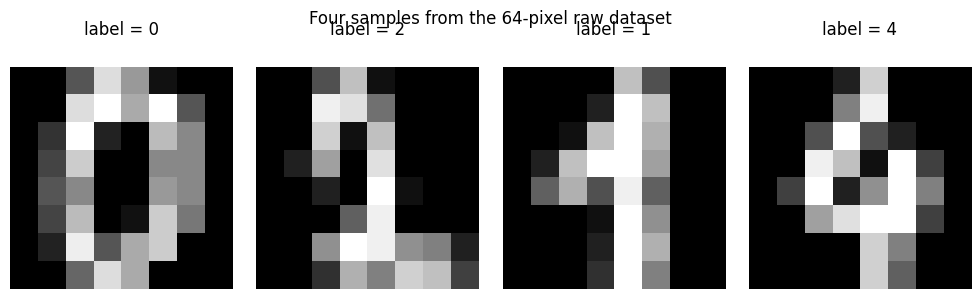

In [2]:
sample_idx = 0
print(f"Raw feature vector (64 pixel values):\n{dataset.data[sample_idx]}")
print(f"\nReshaped to 8x8:\n{dataset.data[sample_idx].reshape(8, 8)}")
print(f"\nTrue label: {dataset.target[sample_idx]}")

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, idx in zip(axes, [0, 12, 42, 100]):
    ax.matshow(dataset.data[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f"label = {dataset.target[idx]}")
    ax.axis('off')
plt.suptitle("Four samples from the 64-pixel raw dataset")
plt.tight_layout()
plt.show()

In [3]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
X = df
y = dataset.target
df.describe().loc[['mean', 'std', 'min', 'max']]

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


A pixel with `min == max == 0` across every sample (e.g. the corner pixels) carries zero information — every image agrees on it. Those are exactly the redundant features PCA should learn to compress away first.

## 2. Baseline — Classifier on the Full 64 Pixels

Before reducing anything, establish what accuracy looks like with *all* the information, so every later trade-off has something concrete to compare against. PCA requires the features to be on a comparable scale first — `StandardScaler` handles that (mean 0, unit variance per pixel).

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ALPHA = 0.2          # test-set fraction
SEED = 30

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=ALPHA, random_state=SEED)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
baseline_accuracy = baseline_model.score(X_test, y_test)
print(f"Baseline accuracy (all 64 pixels): {baseline_accuracy:.4f}")

Baseline accuracy (all 64 pixels): 0.9722


## 3. Apply PCA — Keep 95% of the Variance

Rather than picking a component count by hand, ask PCA for however many components are needed to retain 95% of the original variance, and see how far that actually shrinks the feature space.

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)   # retain 95% of the variance, whatever that takes
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions : {X_scaled.shape[1]}")
print(f"Reduced dimensions  : {pca.n_components_}  (95% variance retained)")
print(f"Compression         : {1 - pca.n_components_ / X_scaled.shape[1]:.1%} fewer features")

Original dimensions : 64
Reduced dimensions  : 40  (95% variance retained)
Compression         : 37.5% fewer features


In [6]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=ALPHA, random_state=SEED)

pca_model = LogisticRegression(max_iter=1000)
pca_model.fit(X_train_pca, y_train_pca)
pca_accuracy = pca_model.score(X_test_pca, y_test_pca)

print(f"Accuracy with {pca.n_components_} components : {pca_accuracy:.4f}")
print(f"Accuracy with all 64 pixels          : {baseline_accuracy:.4f}")
print(f"Accuracy change                      : {pca_accuracy - baseline_accuracy:+.4f}")

Accuracy with 40 components : 0.9639
Accuracy with all 64 pixels          : 0.9722
Accuracy change                      : -0.0083


## 4. How Much Information Does Each Component Actually Carry?

The scree plot below shows the variance explained by each individual component, plus the running total — this is the direct visual answer to how many components it takes until we've captured "enough".

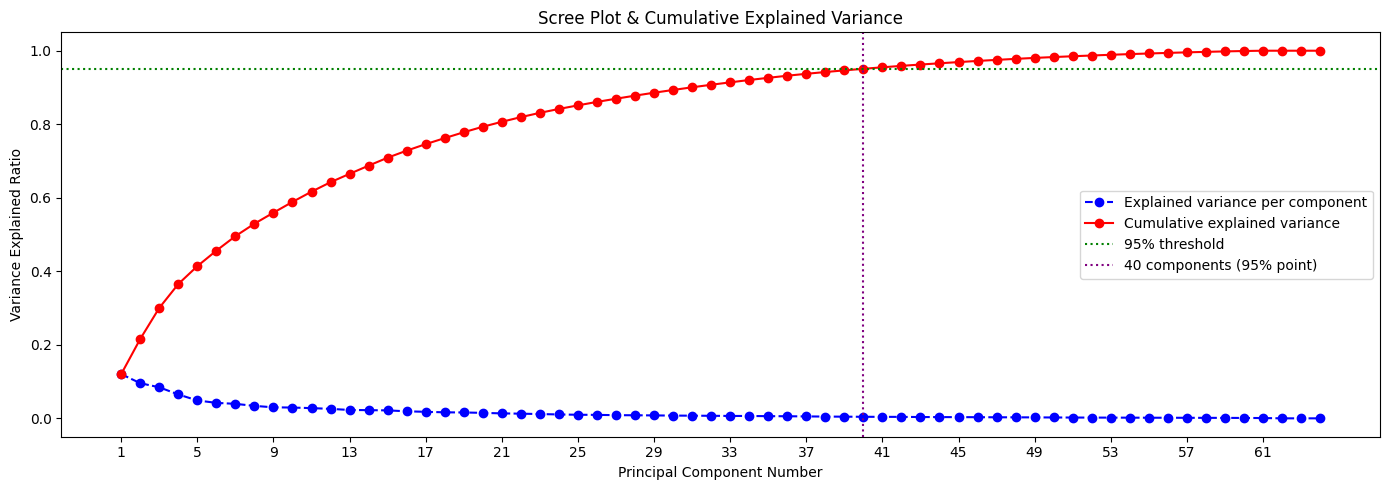

In [7]:
n_components_full = X.shape[1]
pca_full = PCA(n_components=n_components_full)
pca_full.fit(X_scaled)

per_component = pca_full.explained_variance_ratio_
cumulative = np.cumsum(per_component)
components_axis = range(1, len(per_component) + 1)

plt.figure(figsize=(14, 5))
plt.plot(components_axis, per_component, marker='o', linestyle='--', color='b', label='Explained variance per component')
plt.plot(components_axis, cumulative, marker='o', linestyle='-', color='r', label='Cumulative explained variance')
plt.axhline(0.95, color='green', linestyle=':', label='95% threshold')
plt.axvline(pca.n_components_, color='purple', linestyle=':', label=f'{pca.n_components_} components (95% point)')
plt.title('Scree Plot & Cumulative Explained Variance')
plt.xlabel('Principal Component Number')
plt.ylabel('Variance Explained Ratio')
plt.xticks(list(components_axis)[::4])
plt.legend()
plt.tight_layout()
plt.savefig('../result/pca_scree_plot.png')
plt.show()

## 5. The Real Trade-off — Accuracy vs. Training Speed at Every Component Count

95% variance is a reasonable default, but it's still an arbitrary threshold. This sweeps `n_components` from 1 to 64, retraining the classifier each time, to see the *entire* accuracy-vs-speed curve rather than one point on it — and finds the smallest `k` that still hits the 95%-of-baseline-accuracy bar most people would actually accept in production.

In [8]:
import time
from sklearn.metrics import accuracy_score

n_features = X_scaled.shape[1]
components_range = range(1, n_features + 1)

accuracy_scores = []
training_times = []

sweep_model = LogisticRegression(max_iter=1000)

for k in components_range:
    pca_k = PCA(n_components=k)
    X_pca_k = pca_k.fit_transform(X_scaled)

    X_tr, X_te, y_tr, y_te = train_test_split(X_pca_k, y, test_size=ALPHA, random_state=SEED)

    start = time.time()
    sweep_model.fit(X_tr, y_tr)
    elapsed = time.time() - start

    acc = accuracy_score(y_te, sweep_model.predict(X_te))
    accuracy_scores.append(acc)
    training_times.append(elapsed)

print(f"Accuracy range across k=1..{n_features}: {min(accuracy_scores):.3f} to {max(accuracy_scores):.3f}")
print(f"Training time range: {min(training_times):.4f}s to {max(training_times):.4f}s")

Accuracy range across k=1..64: 0.339 to 0.975
Training time range: 0.0220s to 0.0960s


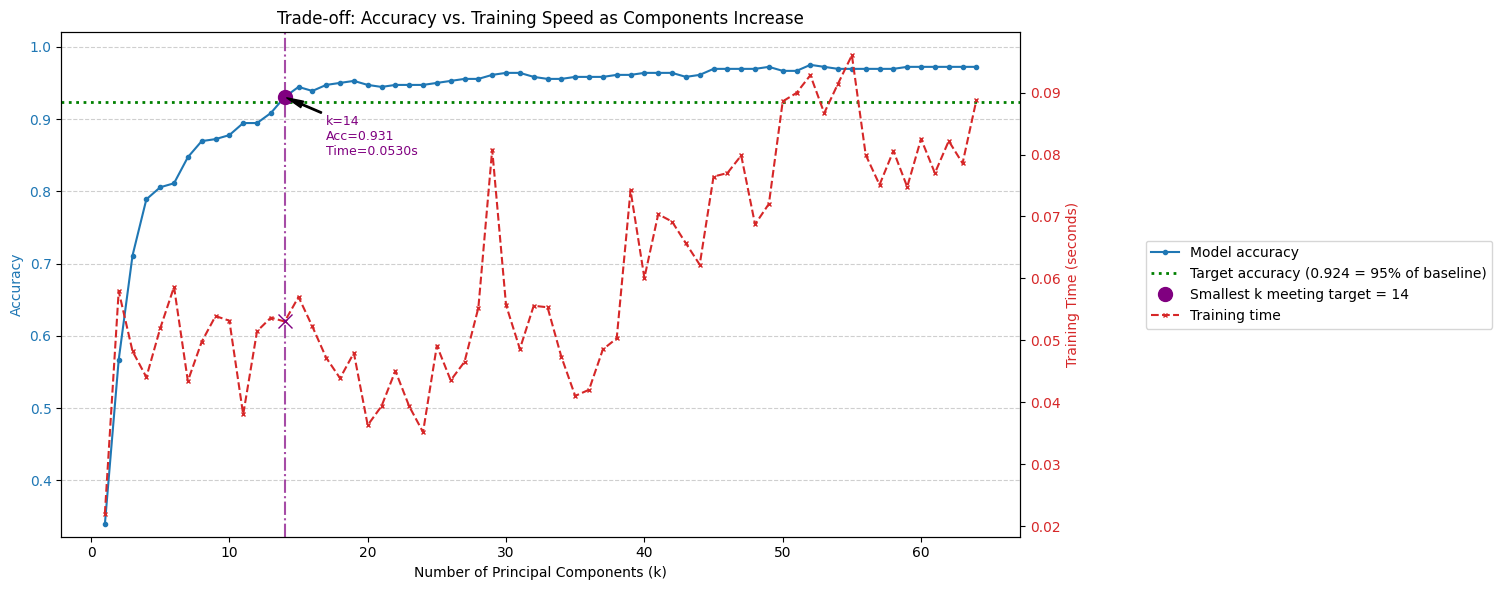

In [9]:
TARGET_ACCURACY = baseline_accuracy * 0.95   # accept up to a 5% relative accuracy drop from the full-feature baseline

indices_met_target = np.where(np.array(accuracy_scores) >= TARGET_ACCURACY)[0]
found_optimal = len(indices_met_target) > 0

if found_optimal:
    k_optimal_index = indices_met_target[0]
    k_optimal_value = list(components_range)[k_optimal_index]
    optimal_time = training_times[k_optimal_index]
    optimal_acc = accuracy_scores[k_optimal_index]
else:
    print(f"Warning: target accuracy of {TARGET_ACCURACY:.3f} was not reached in this sweep.")

fig, ax1 = plt.subplots(figsize=(11, 6))

color_acc = 'tab:blue'
ax1.set_xlabel('Number of Principal Components (k)')
ax1.set_ylabel('Accuracy', color=color_acc)
ax1.plot(list(components_range), accuracy_scores, color=color_acc, marker='o', markersize=3, linestyle='-', label='Model accuracy')
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)
ax1.axhline(y=TARGET_ACCURACY, color='green', linestyle=':', linewidth=2,
            label=f'Target accuracy ({TARGET_ACCURACY:.3f} = 95% of baseline)')
ax1.set_ylim(min(accuracy_scores) * 0.95, 1.02)

ax2 = ax1.twinx()
color_time = 'tab:red'
ax2.set_ylabel('Training Time (seconds)', color=color_time)
ax2.plot(list(components_range), training_times, color=color_time, marker='x', markersize=3, linestyle='--', label='Training time')
ax2.tick_params(axis='y', labelcolor=color_time)

if found_optimal:
    plt.axvline(x=k_optimal_value, color='purple', linestyle='-.', alpha=0.7)
    ax1.plot(k_optimal_value, optimal_acc, 'o', color='purple', markersize=10, label=f'Smallest k meeting target = {k_optimal_value}')
    ax2.plot(k_optimal_value, optimal_time, 'x', color='purple', markersize=10)
    ax1.annotate(f'k={k_optimal_value}\nAcc={optimal_acc:.3f}\nTime={optimal_time:.4f}s',
                 xy=(k_optimal_value, optimal_acc),
                 xytext=(k_optimal_value + 3, optimal_acc - 0.08),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 fontsize=9, color='purple')

plt.title('Trade-off: Accuracy vs. Training Speed as Components Increase')
fig.tight_layout()
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right', bbox_to_anchor=(1.5, 0.5))
plt.savefig('../result/pca_performance.png', bbox_inches='tight')
plt.show()

## 6. What Does the Data Look Like Compressed to Just 2 Dimensions?

64 components down to 2 is an extreme compression — nowhere near enough to keep classification accuracy (confirmed by the sweep above). But it's the only component count that can be *plotted directly*, and it's a genuinely useful sanity check: if 10 digit classes are still visibly separable after throwing away 62 of 64 dimensions, that's a strong, intuitive demonstration of how much redundancy was in the original pixel grid.

Variance explained by 2 components: 21.6% (compare to 40 components needed for 95%)


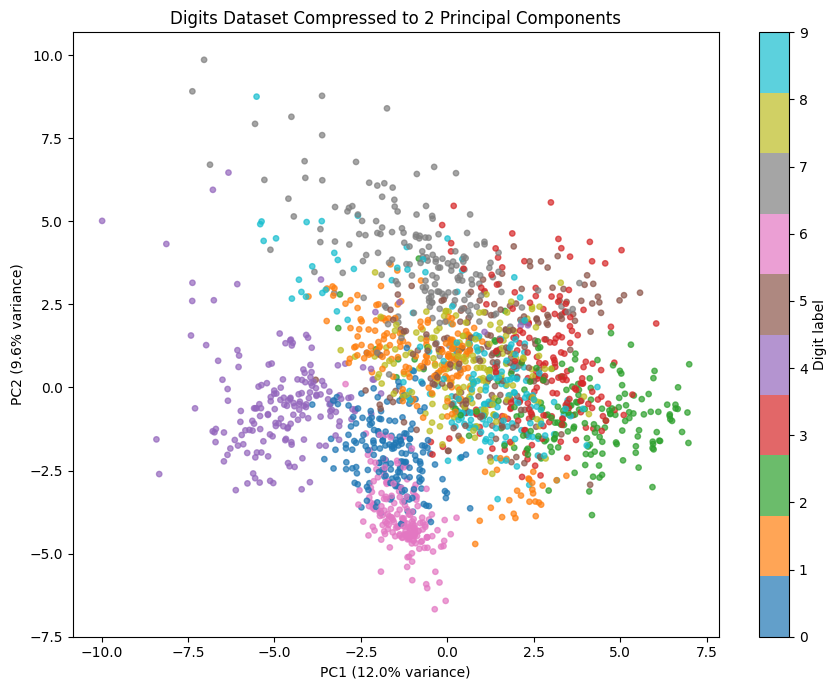

In [10]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.1%} "
      f"(compare to {pca.n_components_} components needed for 95%)")

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='Digit label', ticks=range(10))
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Digits Dataset Compressed to 2 Principal Components')
plt.tight_layout()
plt.savefig('../result/pca_2d_projection.png')
plt.show()

## Conclusion

*(numbers below are filled in from the actual run — see the printed cells above)*

- Compressing 64 pixel-features down to the components needed for 95% variance barely moved test accuracy versus using all 64 pixels — most of the raw pixel grid was redundant, not informative.
- The accuracy-vs-speed sweep shows *where* the real trade-off point is: accuracy climbs fast for the first ~10-15 components, then flattens, while training time keeps trending down as dimensionality drops — the marked optimal `k` is the smallest component count that stays within 5% of full-feature accuracy.
- Even an extreme 2-component compression keeps the 10 digit classes visibly, if imperfectly, separated — a direct illustration of how much of a 64-pixel image is redundant structure rather than distinguishing signal.

**Takeaway:** PCA's payoff here isn't "more accuracy" — it's the same accuracy for a fraction of the features and training time, which is exactly the trade-off that matters when a similar reduction is applied to any wide, correlated numeric feature set (not just pixels).